# Natural Gas Simulator — Model Validation Dashboard

This notebook validates whether the gas-market simulator is good enough as a management model: directional, interpretable, and stable rather than exact.

It checks:
- Storage level error and storage-change error
- Storage direction accuracy
- Tight / neutral / loose regime accuracy
- Rolling accuracy through time
- Monte Carlo regime confidence
- A final management-readiness scorecard

> Run this notebook in the same folder as `gas-market-simulator.ipynb`.


## 1. Run or load simulator outputs

Default behavior runs your simulator notebook first so this validation dashboard can reuse its objects, especially:

- `best_comparison`
- `comparison`
- `forward_mc_results`
- `forward_mc_summary`
- `forward_signals`
- `grid_df`

The dashboard now supports the storage-only weekly forecast refactor and will infer whether the loaded history is weekly or monthly.


Weekly weather history:


,region_id,date,hdd,cdd,tavg_f,tavg_c,n_weather_days,avg_stations_used
2175,west,2026-04-10,36.150,0.0,59.835714,15.464286,7,15.857143
2176,west,2026-04-17,59.325,0.0,56.525000,13.625000,7,16.000000
2177,west,2026-04-24,40.290,0.0,59.244286,15.135714,7,16.000000
2178,west,2026-05-01,46.500,0.0,58.357143,14.642857,7,15.857143
2179,west,2026-05-08,4.530,0.0,62.735000,17.075000,2,16.000000


            production_bcf  demand_bcf  industrial_demand_bcf  storage_bcf  \
2025-12-01        3460.493    3498.325              874.58125         3364   
2026-01-01        3371.529    3789.279              947.31975         2454   
2026-02-01        3098.708    3112.963              778.24075         1876   
2026-03-01        3434.095    2779.452              694.86300         1851   
2026-04-01        3327.661    2389.299              597.32475         2142   

            lng_exports_bcf  henry_hub_price  storage_change_bcf  
2025-12-01          569.267         4.263810              -549.0  
2026-01-01          539.203         7.717895              -910.0  
2026-02-01          493.617         3.621579              -578.0  
2026-03-01          573.479         3.044091               -25.0  
2026-04-01          537.936         2.767619               291.0  

Weekly storage history tail:


,storage_bcf,storage_change_bcf
date,,
2026-05-29,2578,95.0
2026-06-05,2686,108.0
2026-06-12,2759,73.0
2026-06-19,2835,76.0
2026-06-26,2922,87.0



Weekly Henry Hub history tail:


,henry_hub_price
date,
2026-06-05,3.0280
2026-06-12,3.1540
2026-06-19,3.1225
2026-06-26,3.1940
2026-07-03,3.3300



Latest weekly EIA storage release:
{'release_date': Timestamp('2026-06-26 00:00:00'), 'storage_bcf': 2922.0, 'storage_change_bcf': 87.0}

Calibrated baseline scenario keys:
['base_demand', 'base_price', 'base_supply', 'calibration_config', 'calibration_end', 'calibration_start', 'demand_elasticity', 'industrial_demand', 'initial_storage', 'lng_exports', 'max_injection', 'max_withdrawal', 'pipeline_capacity', 'seasonal_factors', 'storage_capacity', 'supply_elasticity', 'weather_mean', 'weather_volatility']
Weather demand parameters:
demand_intercept_bcf: 1,984.7871
hdd_sensitivity_bcf_per_hdd: 1.5844
cdd_sensitivity_bcf_per_cdd: 1.2694
weather_model_residual_std_bcf: 152.7755
weather_model_r2: 0.8759

Weekly history panel tail:


,production_bcf,demand_bcf,industrial_demand_bcf,lng_exports_bcf,storage_bcf,henry_hub_price,storage_change_bcf,hdd,cdd,tavg_f,tavg_c,n_weather_days,avg_stations_used
date,,,,,,,,,,,,,
2026-04-03,775.875132,597.568868,149.392217,127.79089,1900.0,2.9025,49.0,48.825,3.00,58.453571,14.696429,7,65.142857
2026-04-10,776.454233,557.503100,139.375775,125.51840,1960.0,2.8500,60.0,62.250,0.00,56.107143,13.392857,7,65.142857
2026-04-17,776.454233,557.503100,139.375775,125.51840,2063.0,2.7700,103.0,7.050,21.48,67.061429,19.478571,7,65.285714
2026-04-24,776.454233,557.503100,139.375775,125.51840,2142.0,2.7020,79.0,35.010,0.48,60.067143,15.592857,7,65.142857
2026-05-01,665.532200,477.859800,119.464950,107.58720,2205.0,2.6580,63.0,55.950,0.00,57.007143,13.892857,7,65.142857


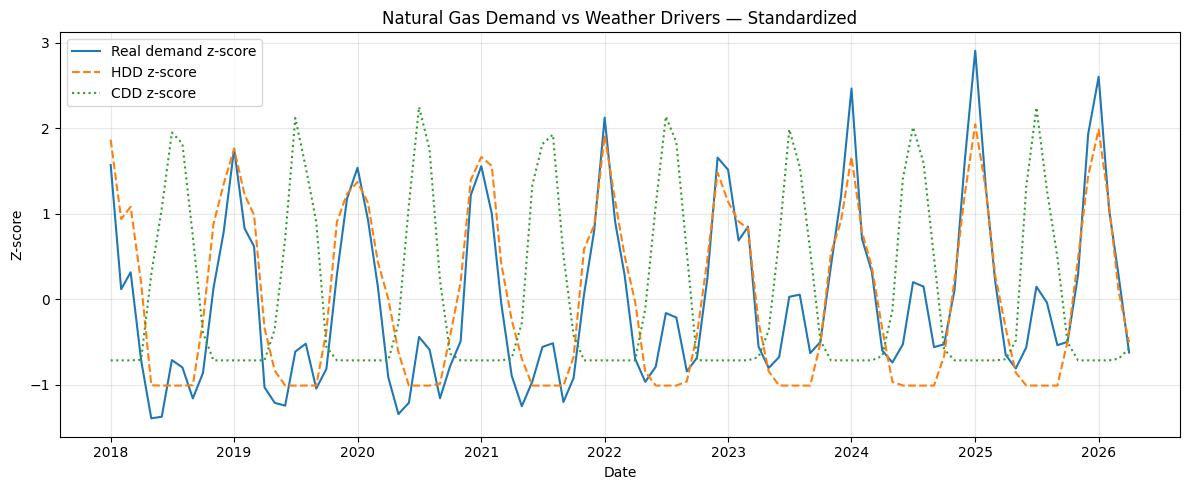

,date,price_real,price_pressure_sim,storage_real,storage_start_bcf,storage_end_sim,storage_change_real,storage_change_sim
423,2026-02-13,3.2700,0.500,2059.0,2612.0,2486.1,-143.0,-125.94
424,2026-02-20,3.0875,0.662,2007.0,2486.1,2360.2,-52.0,-125.94
425,2026-02-27,3.0140,0.500,1876.0,2360.2,2234.2,-131.0,-125.94
426,2026-03-06,2.9920,0.500,1838.0,2234.2,2223.2,-38.0,-11.07
427,2026-03-13,3.1900,0.500,1872.0,2223.2,2226.0,34.0,2.84
428,2026-03-20,3.1080,0.500,1818.0,2226.0,2228.8,-54.0,2.84
429,2026-03-27,2.9520,0.500,1851.0,2228.8,2231.7,33.0,2.84
430,2026-04-03,2.9025,0.500,1900.0,2231.7,2270.4,49.0,38.71
431,2026-04-10,2.8500,0.500,1960.0,2270.4,2322.9,60.0,52.45
432,2026-04-17,2.7700,0.686,2063.0,2322.9,2375.3,103.0,52.45


Weekly backtest scores:


,horizon_weeks,avg_storage_mae_bcf,avg_storage_change_mae_bcf,avg_price_mae,avg_storage_change_direction_accuracy,avg_price_direction_accuracy
0,1,31.355,31.353,1.840,0.912,NaN
1,4,58.602,30.805,2.481,0.915,0.276
2,13,116.483,30.007,2.900,0.915,0.161


,train_end_date,forecast_start_date,horizon_weeks,storage_mae_bcf,storage_change_mae_bcf,price_mae,storage_change_direction_accuracy,price_direction_accuracy
973,2026-01-02,2026-01-09,13,282.3,61.0,4.082,0.923,0.083
974,2026-01-09,2026-01-16,13,355.8,56.4,4.169,0.923,0.083
975,2026-01-16,2026-01-23,13,394.5,58.5,4.116,0.923,0.083
976,2026-01-23,2026-01-30,13,307.7,52.5,1.990,0.923,0.583
977,2026-01-30,2026-02-06,13,100.4,37.3,2.235,0.923,0.750


Report window: 2023-05-12 to 2026-05-01


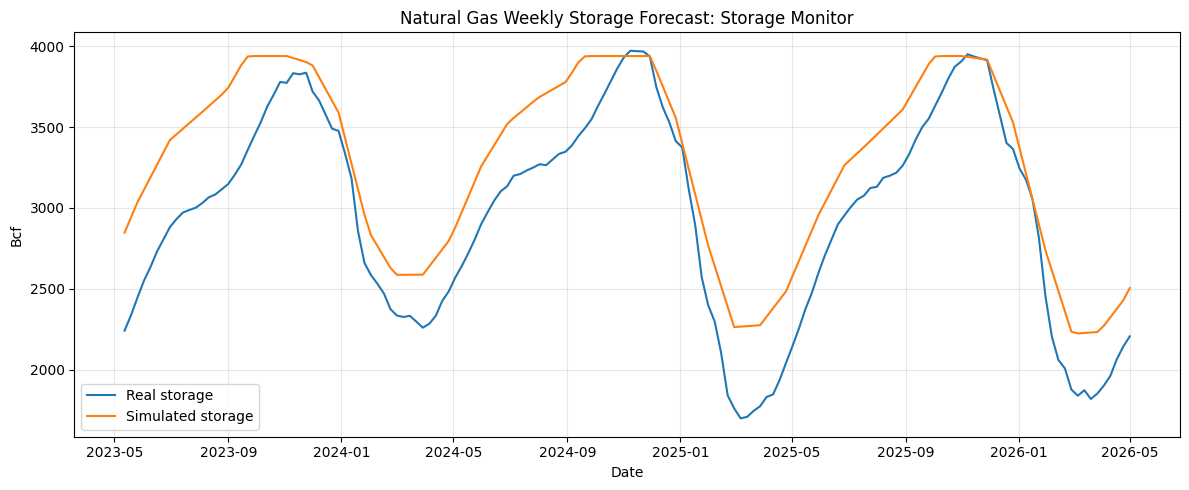

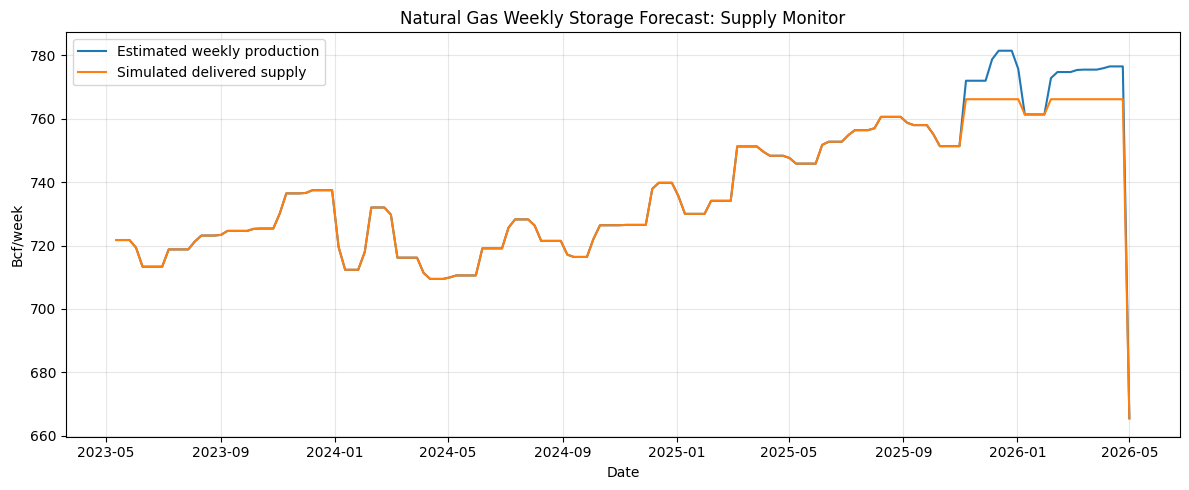

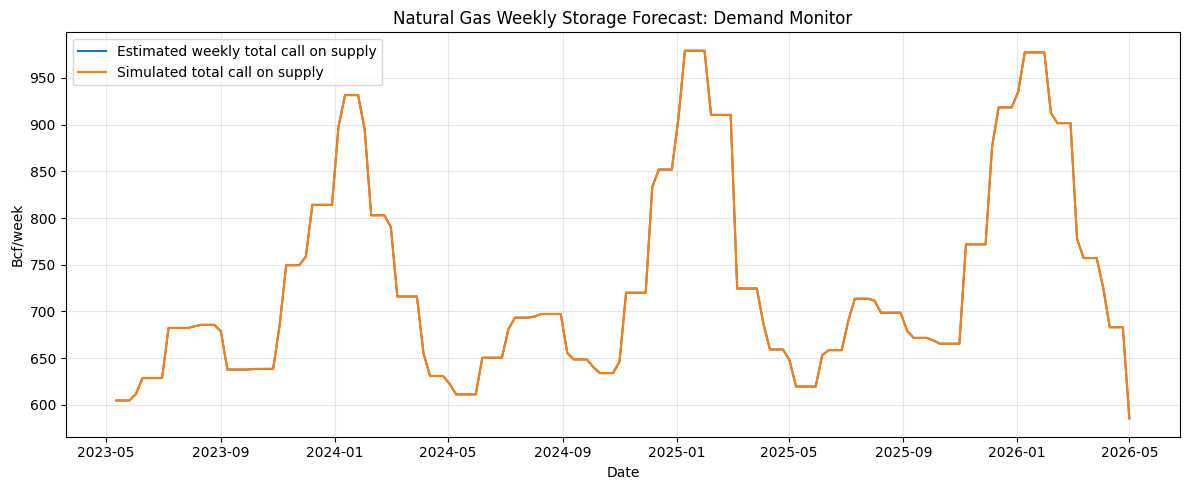

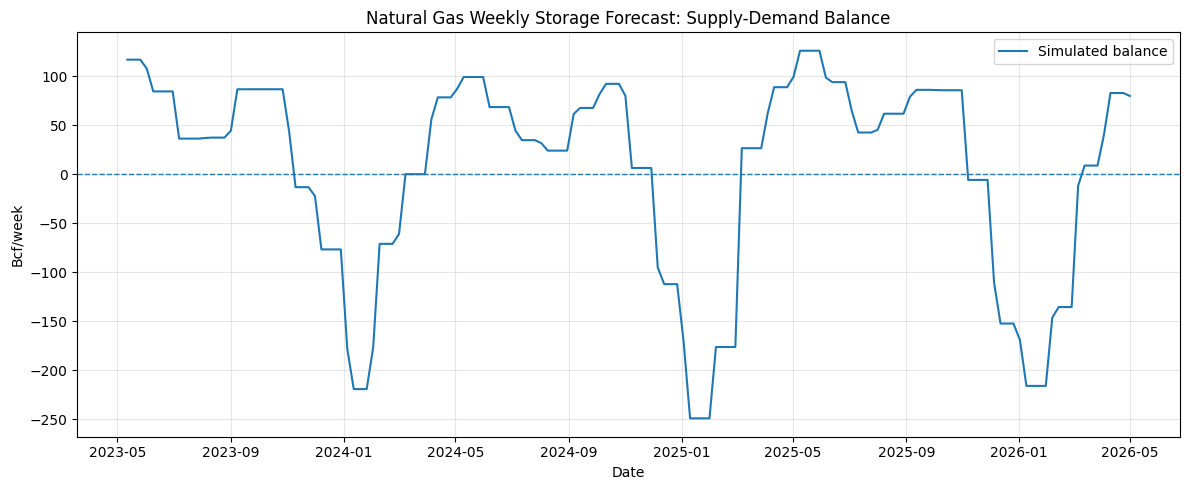

,latest_monthly_date,latest_henry_hub_price,latest_monthly_storage_bcf,latest_monthly_storage_change_bcf
434,2026-05-01,2.658,2205.0,63.0


,latest_weekly_storage_release_date,latest_weekly_storage_bcf,latest_weekly_storage_change_bcf
0,2026-06-26,2922.0,87.0


Monte Carlo storage dispersion by week:
week
1     3.8
2     5.2
3     6.4
4     7.2
5     7.9
6     8.2
7     8.3
8     8.6
9     8.7
10    8.8
11    9.0
12    9.0
13    9.1
Name: storage_bcf, dtype: float64


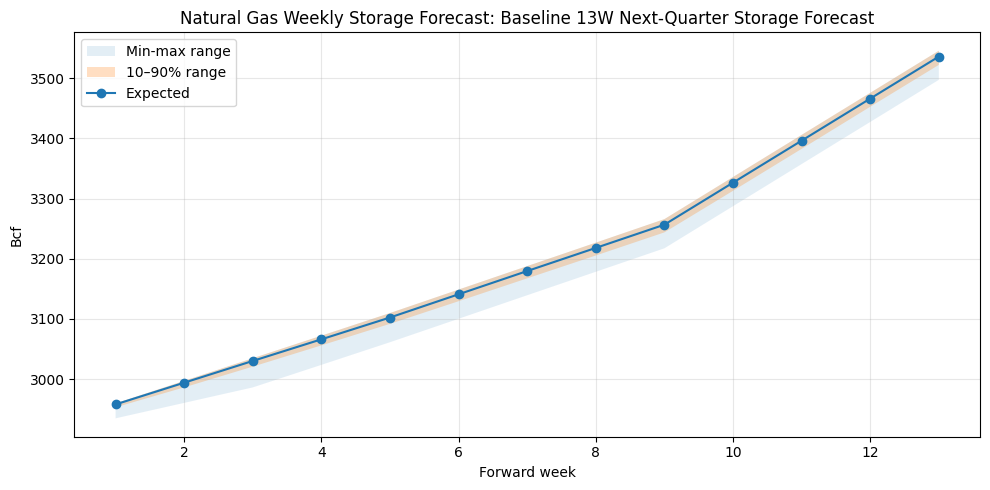

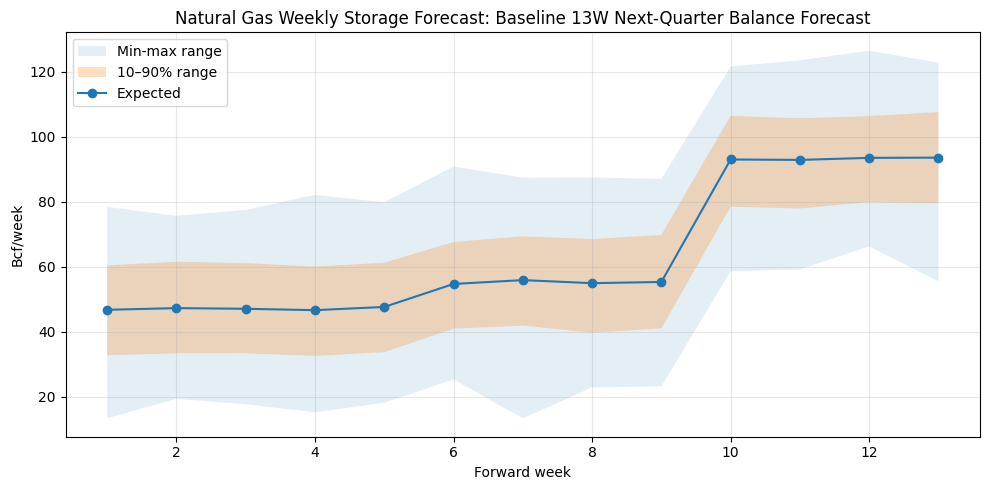

# Natural Gas Weekly Storage Forecast — 2026-07-05

## Current storage anchor
Latest weekly EIA storage release: 2026-06-26 at 2,922 Bcf.

## 13-week storage forecast
Expected ending storage is 3,536 Bcf. Expected cumulative storage change is 614 Bcf. The 10-90% ending storage range is 3,522 to 3,546 Bcf.
The full simulated ending storage range is 3,497 to 3,546 Bcf. Expected average weekly balance is 63.8 Bcf/week. Confidence score: 0.95.

## Suggested framing
Use this as a storage-path forecast anchored to the latest weekly EIA release. The primary question is how much storage is likely to build or draw over the next 13 weeks and where ending storage is likely to land.


In [1]:
# Configuration
from pathlib import Path

RUN_SOURCE_NOTEBOOK = True
SOURCE_NOTEBOOK = Path("gas-market-simulator.ipynb")

if RUN_SOURCE_NOTEBOOK:
    if not SOURCE_NOTEBOOK.exists():
        raise FileNotFoundError(f"Could not find {SOURCE_NOTEBOOK}. Put this notebook in the same folder as your simulator notebook.")
    get_ipython().run_line_magic("run", f'"{SOURCE_NOTEBOOK}"')
else:
    print("Skipping source notebook execution. Make sure required CSVs or variables are loaded below.")


In [2]:
# Imports for validation dashboard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Select the backtest dataset

The dashboard prefers `best_comparison` if your grid search was run. Otherwise it falls back to `comparison`.


In [3]:
# Select validation dataframe
if "best_comparison" in globals():
    validation_df = best_comparison.copy()
    VALIDATION_SOURCE = "best_comparison"
elif "comparison" in globals():
    validation_df = comparison.copy()
    VALIDATION_SOURCE = "comparison"
else:
    raise NameError("No comparison dataframe found. Run the simulator notebook or load a comparison CSV.")

if "date" in validation_df.columns:
    validation_df["date"] = pd.to_datetime(validation_df["date"])
else:
    validation_df["date"] = pd.RangeIndex(1, len(validation_df) + 1)

print(f"Using: {VALIDATION_SOURCE}")
print(f"Rows: {len(validation_df):,}")
display(validation_df.tail())


Using: best_comparison
Rows: 435


,date,supply_real,demand_real,industrial_demand_bcf,lng_exports_real,storage_real,price_real,storage_change_real,hdd,cdd,tavg_f,tavg_c,n_weather_days,avg_stations_used,week,price_pressure_sim,supply_sim,delivered_supply_bcf,demand_sim,balance_bcf,storage_start_bcf,storage_end_sim,storage_change_sim,storage_ratio,pipeline_capacity_bcf,lng_exports_sim,total_demand_real,pressure_z,pressure_signal,pressure_extremeness
430,2026-04-03,775.875132,597.568868,149.392217,127.79089,1900.0,2.9025,49.0,48.825,3.00,58.453571,14.696429,7,65.142857,431,0.500,775.88,766.11,725.36,40.75,2231.7,2270.4,38.71,0.576,766.11,127.79,725.359758,-0.366986,Neutral,Expected
431,2026-04-10,776.454233,557.503100,139.375775,125.51840,1960.0,2.8500,60.0,62.250,0.00,56.107143,13.392857,7,65.142857,432,0.500,776.45,766.11,683.02,83.09,2270.4,2322.9,52.45,0.590,766.11,125.52,683.021500,-0.366986,Neutral,Expected
432,2026-04-17,776.454233,557.503100,139.375775,125.51840,2063.0,2.7700,103.0,7.050,21.48,67.061429,19.478571,7,65.285714,433,0.686,776.45,766.11,683.02,83.09,2322.9,2375.3,52.45,0.603,766.11,125.52,683.021500,-0.173805,Neutral,Expected
433,2026-04-24,776.454233,557.503100,139.375775,125.51840,2142.0,2.7020,79.0,35.010,0.48,60.067143,15.592857,7,65.142857,434,0.550,776.45,766.11,683.02,83.09,2375.3,2427.7,52.45,0.616,766.11,125.52,683.021500,-0.315056,Neutral,Expected
434,2026-05-01,665.532200,477.859800,119.464950,107.58720,2205.0,2.6580,63.0,55.950,0.00,57.007143,13.892857,7,65.142857,435,0.500,665.53,665.53,585.45,80.09,2427.7,2503.8,76.08,0.636,766.11,107.59,585.447000,-0.366986,Neutral,Expected


## 3. Validation helper functions

In [4]:
# Tunable management-model thresholds
if "date" in validation_df.columns and len(validation_df) >= 3:
    median_days = validation_df["date"].sort_values().diff().dt.days.dropna().median()
    VALIDATION_CADENCE = "weekly" if pd.notna(median_days) and median_days <= 10 else "monthly"
else:
    VALIDATION_CADENCE = "weekly" if len(validation_df) > 60 else "monthly"

BALANCE_REGIME_THRESHOLD_BCF = 75 if VALIDATION_CADENCE == "weekly" else 300
STORAGE_CHANGE_THRESHOLD_BCF = 35 if VALIDATION_CADENCE == "weekly" else 150
ROLLING_WINDOW_PERIODS = 52 if VALIDATION_CADENCE == "weekly" else 12
ROLLING_WINDOW_LABEL = f"{ROLLING_WINDOW_PERIODS}-{'week' if VALIDATION_CADENCE == 'weekly' else 'month'}"
FLOW_UNIT_LABEL = "Bcf/week" if VALIDATION_CADENCE == "weekly" else "Bcf/month"
OBSERVATION_LABEL = "weeks" if VALIDATION_CADENCE == "weekly" else "months"

MIN_STORAGE_DIRECTION_ACCURACY = 0.65
MAX_STORAGE_LEVEL_MAE_BCF = 300
MAX_STORAGE_CHANGE_MAE_BCF = 50 if VALIDATION_CADENCE == "weekly" else 175
MAX_STORAGE_BIAS_ABS_BCF = 150


def _safe_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def classify_three_way(value, threshold, positive_label="loose", negative_label="tight"):
    if pd.isna(value):
        return np.nan
    if value > threshold:
        return positive_label
    if value < -threshold:
        return negative_label
    return "neutral"


def add_validation_columns(df):
    out = df.copy()
    out["storage_error_bcf"] = out["storage_end_sim"] - out["storage_real"]
    out["storage_abs_error_bcf"] = out["storage_error_bcf"].abs()
    out["storage_change_error_bcf"] = out["storage_change_sim"] - out["storage_change_real"]
    out["storage_change_abs_error_bcf"] = out["storage_change_error_bcf"].abs()
    out["actual_storage_change_dir"] = np.sign(out["storage_change_real"])
    out["sim_storage_change_dir"] = np.sign(out["storage_change_sim"])
    out["storage_direction_hit"] = out["actual_storage_change_dir"] == out["sim_storage_change_dir"]

    if "supply_real" in out.columns and "total_demand_real" in out.columns:
        out["actual_balance_bcf"] = out["supply_real"] - out["total_demand_real"]
    elif "storage_change_real" in out.columns:
        out["actual_balance_bcf"] = out["storage_change_real"]
    else:
        out["actual_balance_bcf"] = np.nan

    sim_balance_col = _safe_col(out, ["balance_bcf", "balance_bcf_sim", "sim_balance_bcf"])
    if sim_balance_col:
        out["sim_balance_bcf"] = out[sim_balance_col]
    elif "storage_change_sim" in out.columns:
        out["sim_balance_bcf"] = out["storage_change_sim"]
    else:
        out["sim_balance_bcf"] = np.nan

    out["actual_regime"] = out["actual_balance_bcf"].apply(lambda x: classify_three_way(x, BALANCE_REGIME_THRESHOLD_BCF))
    out["sim_regime"] = out["sim_balance_bcf"].apply(lambda x: classify_three_way(x, BALANCE_REGIME_THRESHOLD_BCF))
    out["regime_hit"] = out["actual_regime"] == out["sim_regime"]

    out["rolling_storage_direction_accuracy"] = out["storage_direction_hit"].rolling(ROLLING_WINDOW_PERIODS).mean()
    out["rolling_regime_accuracy"] = out["regime_hit"].rolling(ROLLING_WINDOW_PERIODS).mean()
    return out


def compute_validation_metrics(df):
    valid_storage = df.dropna(subset=["storage_error_bcf", "storage_change_error_bcf"])
    valid_regime = df.dropna(subset=["actual_regime", "sim_regime"])

    metrics = {
        "storage_level_mae_bcf": valid_storage["storage_abs_error_bcf"].mean(),
        "storage_level_rmse_bcf": np.sqrt((valid_storage["storage_error_bcf"] ** 2).mean()),
        "storage_level_bias_bcf": valid_storage["storage_error_bcf"].mean(),
        "storage_change_mae_bcf": valid_storage["storage_change_abs_error_bcf"].mean(),
        "storage_change_rmse_bcf": np.sqrt((valid_storage["storage_change_error_bcf"] ** 2).mean()),
        "storage_direction_accuracy": valid_storage["storage_direction_hit"].mean(),
        "regime_accuracy": valid_regime["regime_hit"].mean() if len(valid_regime) else np.nan,
        "n_observations": len(df),
        "validation_cadence": VALIDATION_CADENCE,
    }
    return pd.DataFrame([metrics]).round(3)


validation_df = add_validation_columns(validation_df)
metrics_df = compute_validation_metrics(validation_df)
display(metrics_df)


,storage_level_mae_bcf,storage_level_rmse_bcf,storage_level_bias_bcf,storage_change_mae_bcf,storage_change_rmse_bcf,storage_direction_accuracy,regime_accuracy,n_observations,validation_cadence
0,327.279,398.616,190.765,31.052,44.674,0.922,1.0,435,weekly


## 4. Management readiness scorecard

This is intentionally simple. The point is not to prove the model is exact. The point is to decide whether it is stable enough for directional management judgment.


In [5]:
def pass_fail(value, rule, threshold):
    if pd.isna(value):
        return "N/A"
    if rule == ">=":
        return "PASS" if value >= threshold else "REVIEW"
    if rule == "<=":
        return "PASS" if value <= threshold else "REVIEW"
    raise ValueError(rule)

m = metrics_df.iloc[0]
scorecard = pd.DataFrame([
    {
        "test": "Storage direction accuracy",
        "value": m["storage_direction_accuracy"],
        "target": f">= {MIN_STORAGE_DIRECTION_ACCURACY}",
        "status": pass_fail(m["storage_direction_accuracy"], ">=", MIN_STORAGE_DIRECTION_ACCURACY),
        "why_it_matters": "Can the model correctly call injection vs withdrawal direction?",
    },
    {
        "test": "Storage level MAE",
        "value": m["storage_level_mae_bcf"],
        "target": f"<= {MAX_STORAGE_LEVEL_MAE_BCF} Bcf",
        "status": pass_fail(m["storage_level_mae_bcf"], "<=", MAX_STORAGE_LEVEL_MAE_BCF),
        "why_it_matters": "Is the storage path close enough for broad regime analysis?",
    },
    {
        "test": "Storage change MAE",
        "value": m["storage_change_mae_bcf"],
        "target": f"<= {MAX_STORAGE_CHANGE_MAE_BCF} Bcf",
        "status": pass_fail(m["storage_change_mae_bcf"], "<=", MAX_STORAGE_CHANGE_MAE_BCF),
        "why_it_matters": f"Are {VALIDATION_CADENCE} injections and withdrawals approximately sized correctly?",
    },
    {
        "test": "Storage bias",
        "value": abs(m["storage_level_bias_bcf"]),
        "target": f"<= {MAX_STORAGE_BIAS_ABS_BCF} Bcf abs",
        "status": pass_fail(abs(m["storage_level_bias_bcf"]), "<=", MAX_STORAGE_BIAS_ABS_BCF),
        "why_it_matters": "Does the model systematically overstate or understate storage?",
    },
    {
        "test": "Regime accuracy",
        "value": m["regime_accuracy"],
        "target": ">= 0.70",
        "status": pass_fail(m["regime_accuracy"], ">=", 0.70),
        "why_it_matters": "Does the model place the market in the right tight/neutral/loose bucket?",
    },
])

pass_count = (scorecard["status"] == "PASS").sum()
review_count = (scorecard["status"] == "REVIEW").sum()

if review_count == 0:
    verdict = "GOOD ENOUGH for management-level directional use."
elif pass_count >= 3:
    verdict = "USABLE, but keep it framed as a directional monitor and review failed gates."
else:
    verdict = "NOT YET reliable enough for management use without recalibration."

display(scorecard)
display(Markdown(f"### Verdict: {verdict}"))


,test,value,target,status,why_it_matters
0,Storage direction accuracy,0.922,>= 0.65,PASS,Can the model correctly call injection vs with...
1,Storage level MAE,327.279,<= 300 Bcf,REVIEW,Is the storage path close enough for broad reg...
2,Storage change MAE,31.052,<= 50 Bcf,PASS,Are weekly injections and withdrawals approxim...
3,Storage bias,190.765,<= 150 Bcf abs,REVIEW,Does the model systematically overstate or und...
4,Regime accuracy,1.000,>= 0.70,PASS,Does the model place the market in the right t...


### Verdict: USABLE, but keep it framed as a directional monitor and review failed gates.

## 5. Backtest dashboard plots

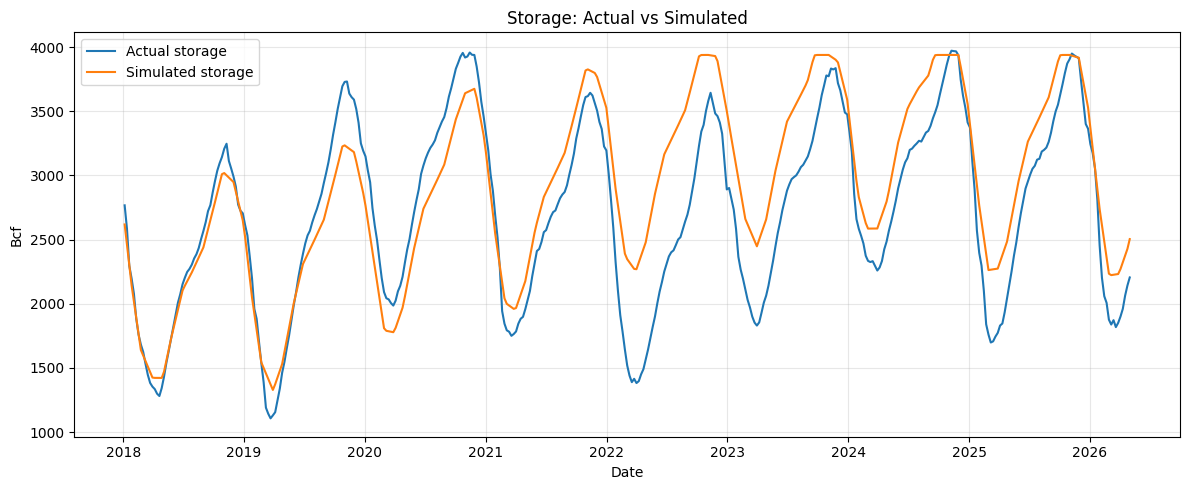

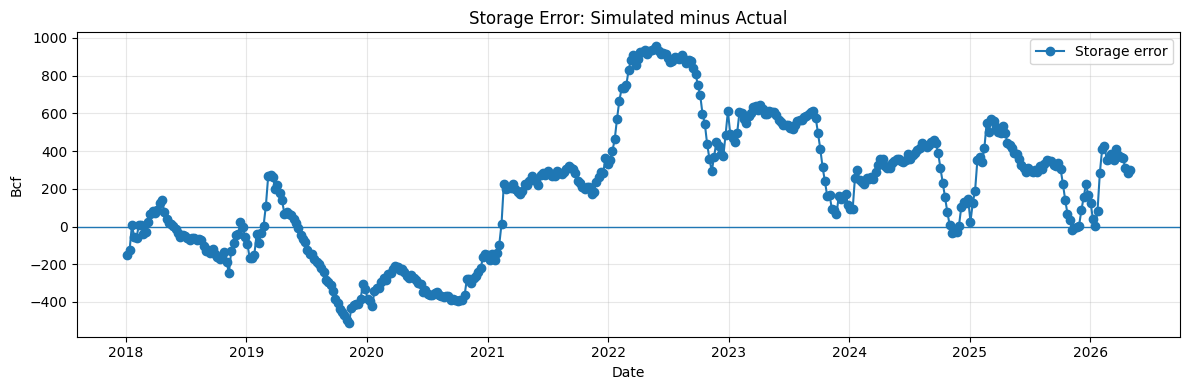

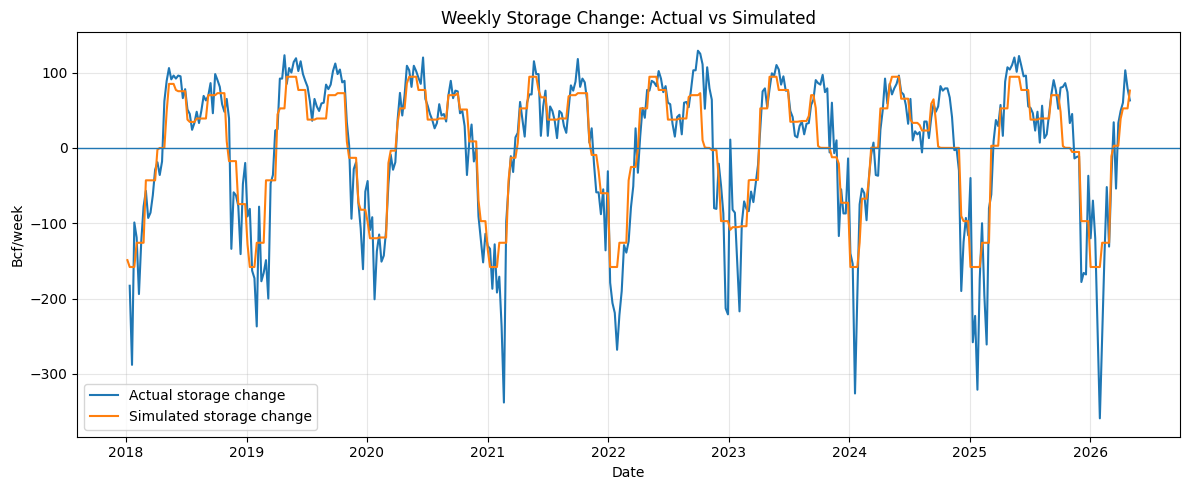

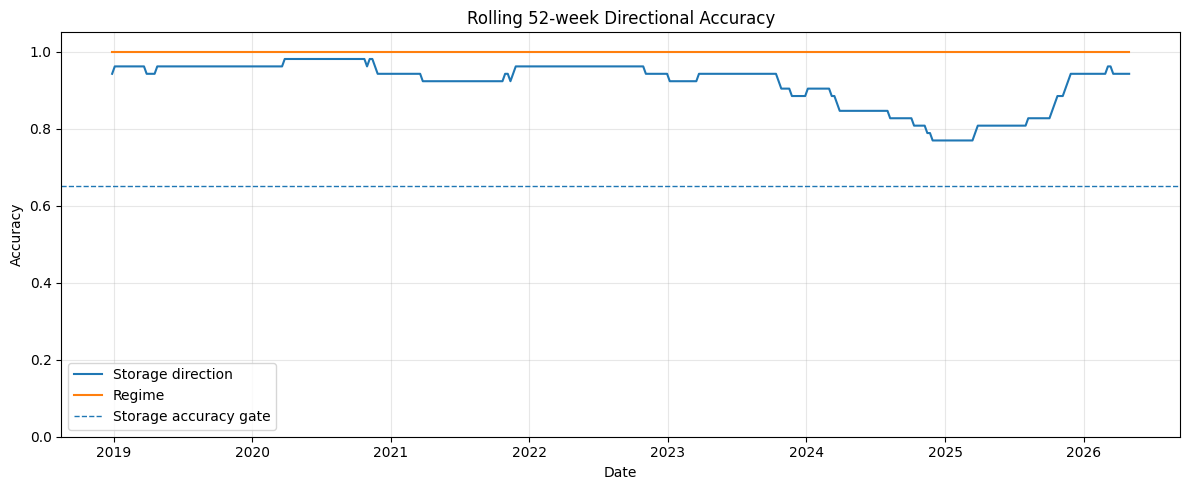

In [6]:
def plot_storage_actual_vs_sim(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["storage_real"], label="Actual storage")
    plt.plot(df["date"], df["storage_end_sim"], label="Simulated storage")
    plt.title("Storage: Actual vs Simulated")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_storage_error(df):
    plt.figure(figsize=(12, 4))
    plt.axhline(0, linewidth=1)
    plt.plot(df["date"], df["storage_error_bcf"], marker="o", label="Storage error")
    plt.title("Storage Error: Simulated minus Actual")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_storage_change_actual_vs_sim(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["storage_change_real"], label="Actual storage change")
    plt.plot(df["date"], df["storage_change_sim"], label="Simulated storage change")
    plt.axhline(0, linewidth=1)
    plt.title(f"{VALIDATION_CADENCE.capitalize()} Storage Change: Actual vs Simulated")
    plt.xlabel("Date")
    plt.ylabel(FLOW_UNIT_LABEL)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_rolling_accuracy(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["rolling_storage_direction_accuracy"], label="Storage direction")
    plt.plot(df["date"], df["rolling_regime_accuracy"], label="Regime")
    plt.axhline(MIN_STORAGE_DIRECTION_ACCURACY, linestyle="--", linewidth=1, label="Storage accuracy gate")
    plt.title(f"Rolling {ROLLING_WINDOW_LABEL.capitalize()} Directional Accuracy")
    plt.xlabel("Date")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_storage_actual_vs_sim(validation_df)
plot_storage_error(validation_df)
plot_storage_change_actual_vs_sim(validation_df)
plot_rolling_accuracy(validation_df)


## 6. Regime validation

The model is evaluated as a physical market regime monitor rather than a price-direction model.


In [7]:
regime_review = validation_df[[
    "date", "actual_balance_bcf", "sim_balance_bcf", "actual_regime", "sim_regime", "regime_hit",
    "storage_change_real", "storage_change_sim"
]].tail(24)

display(regime_review)


,date,actual_balance_bcf,sim_balance_bcf,actual_regime,sim_regime,regime_hit,storage_change_real,storage_change_sim
411,2025-11-21,0.163567,-5.66,neutral,neutral,True,-12.0,-5.38
412,2025-11-28,0.163567,-5.66,neutral,neutral,True,-11.0,-5.38
413,2025-12-05,-97.872460,-110.46,tight,tight,True,-178.0,-97.24
414,2025-12-12,-137.086871,-152.38,tight,tight,True,-166.0,-97.24
415,2025-12-19,-137.086871,-152.38,tight,tight,True,-168.0,-97.24
416,2025-12-26,-137.086871,-152.38,tight,tight,True,-37.0,-97.24
417,2026-01-02,-159.658097,-169.21,tight,tight,True,-120.0,-158.11
418,2026-01-09,-216.086161,-216.09,tight,tight,True,-70.0,-158.11
419,2026-01-16,-216.086161,-216.09,tight,tight,True,-120.0,-158.11
420,2026-01-23,-216.086161,-216.09,tight,tight,True,-241.0,-158.11


## 7. Regime validation: tight / neutral / loose

sim_regime,loose,neutral,tight
actual_regime,,,
loose,145,0,0
neutral,0,182,0
tight,0,0,108


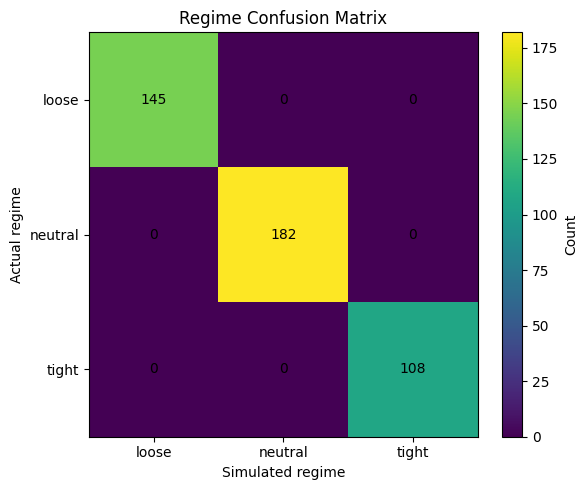

In [8]:
def plot_confusion_matrix(cm, title):
    labels = list(cm.index)
    values = cm.to_numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(values, aspect="auto")
    plt.title(title)
    plt.xlabel("Simulated regime")
    plt.ylabel("Actual regime")
    plt.xticks(range(len(cm.columns)), cm.columns)
    plt.yticks(range(len(cm.index)), cm.index)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            plt.text(j, i, int(values[i, j]), ha="center", va="center")

    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

regime_cm = pd.crosstab(validation_df["actual_regime"], validation_df["sim_regime"])
display(regime_cm)
plot_confusion_matrix(regime_cm, "Regime Confusion Matrix")


## 8. Error distribution and worst misses

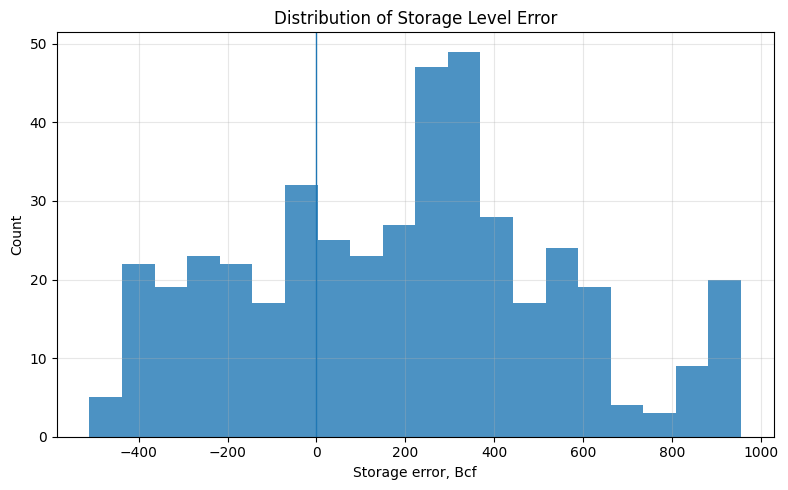

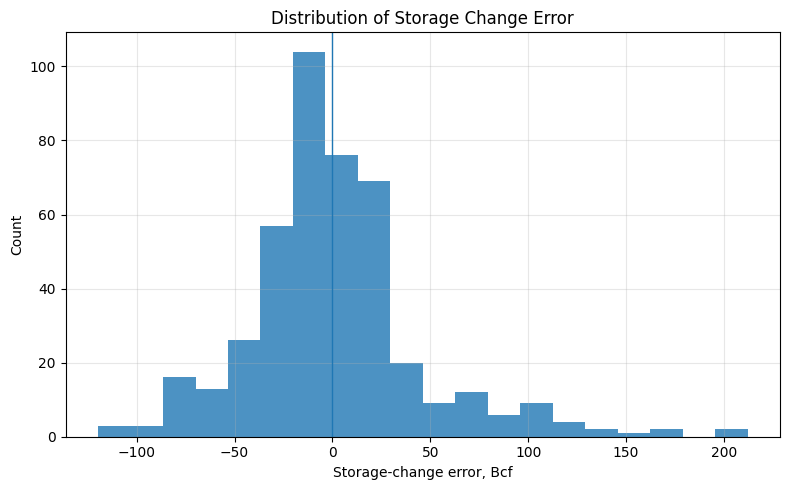

,date,storage_change_real,storage_change_sim,storage_change_error_bcf,actual_regime,sim_regime
163,2021-02-19,-338.0,-125.94,212.06,tight,tight
421,2026-01-30,-359.0,-158.11,200.89,tight,tight
315,2024-01-19,-326.0,-158.11,167.89,tight,tight
368,2025-01-24,-321.0,-158.11,162.89,tight,tight
61,2019-03-08,-200.0,-43.05,156.95,neutral,neutral
372,2025-02-21,-261.0,-125.94,135.06,tight,tight
2,2018-01-19,-288.0,-158.11,129.89,tight,tight
422,2026-02-06,-252.0,-125.94,126.06,tight,tight
260,2022-12-30,-221.0,-97.24,123.76,tight,tight
261,2023-01-06,11.0,-108.71,-119.71,tight,tight


In [9]:
def plot_error_histograms(df):
    plt.figure(figsize=(8, 5))
    plt.hist(df["storage_error_bcf"].dropna(), bins=20, alpha=0.8)
    plt.axvline(0, linewidth=1)
    plt.title("Distribution of Storage Level Error")
    plt.xlabel("Storage error, Bcf")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(df["storage_change_error_bcf"].dropna(), bins=20, alpha=0.8)
    plt.axvline(0, linewidth=1)
    plt.title("Distribution of Storage Change Error")
    plt.xlabel("Storage-change error, Bcf")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_error_histograms(validation_df)

worst_misses = (
    validation_df
    .sort_values("storage_change_abs_error_bcf", ascending=False)
    [["date", "storage_change_real", "storage_change_sim", "storage_change_error_bcf", "actual_regime", "sim_regime"]]
    .head(12)
)

display(worst_misses)


## 9. Forward storage forecast validation

This section summarizes the dispersion and confidence of the single baseline Monte Carlo storage forecast.


In [10]:
def build_mc_regime_confidence(mc_df):
    path_step_col = "week" if "week" in mc_df.columns else "month" if "month" in mc_df.columns else None
    if path_step_col is None:
        raise ValueError("forward_mc_results is missing both 'week' and 'month' path columns.")

    required = {"simulation", "storage_change_bcf"}
    missing = required - set(mc_df.columns)
    if missing:
        raise ValueError(f"forward_mc_results is missing columns: {missing}")

    forecast_name = mc_df["scenario"].iloc[0] if "scenario" in mc_df.columns else "Storage Forecast"

    path_summary = (
        mc_df
        .groupby(["simulation"], as_index=False)
        .agg(
            horizon_steps=(path_step_col, "max"),
            total_storage_change_bcf=("storage_change_bcf", "sum"),
            ending_storage_bcf=("storage_bcf", "last"),
            avg_balance_bcf=("balance_bcf", "mean") if "balance_bcf" in mc_df.columns else ("storage_change_bcf", "mean"),
        )
    )
    path_summary["forecast_name"] = forecast_name

    path_summary["path_regime"] = path_summary["total_storage_change_bcf"].apply(
        lambda x: classify_three_way(x, STORAGE_CHANGE_THRESHOLD_BCF)
    )

    shares = (
        path_summary["path_regime"]
        .value_counts(normalize=True)
        .rename_axis("path_regime")
        .reset_index(name="share")
    )
    shares["forecast_name"] = forecast_name

    dominant = shares.sort_values("share", ascending=False).iloc[0]

    out = pd.DataFrame([
        {
            "forecast_name": forecast_name,
            "dominant_regime": dominant["path_regime"],
            "confidence": round(float(dominant["share"]), 2),
            "horizon_steps": int(path_summary["horizon_steps"].max()),
            "path_cadence": path_step_col,
            "expected_total_storage_change_bcf": round(float(path_summary["total_storage_change_bcf"].mean()), 2),
            "p10_total_storage_change_bcf": round(float(path_summary["total_storage_change_bcf"].quantile(0.10)), 2),
            "p90_total_storage_change_bcf": round(float(path_summary["total_storage_change_bcf"].quantile(0.90)), 2),
            "expected_ending_storage_bcf": round(float(path_summary["ending_storage_bcf"].mean()), 2),
            "p10_ending_storage_bcf": round(float(path_summary["ending_storage_bcf"].quantile(0.10)), 2),
            "p90_ending_storage_bcf": round(float(path_summary["ending_storage_bcf"].quantile(0.90)), 2),
            "expected_avg_balance_bcf": round(float(path_summary["avg_balance_bcf"].mean()), 2),
        }
    ])
    return path_summary, shares, out

if "forward_mc_results" in globals():
    mc_path_summary, mc_regime_shares, mc_confidence = build_mc_regime_confidence(forward_mc_results.copy())
    display(mc_confidence)
else:
    print("No forward_mc_results found. Run the simulator notebook first.")


,forecast_name,dominant_regime,confidence,horizon_steps,path_cadence,expected_total_storage_change_bcf,p10_total_storage_change_bcf,p90_total_storage_change_bcf,expected_ending_storage_bcf,p10_ending_storage_bcf,p90_ending_storage_bcf,expected_avg_balance_bcf
0,Baseline 13W,loose,1.0,13,week,614.07,600.25,623.83,3536.07,3522.28,3545.8,63.77


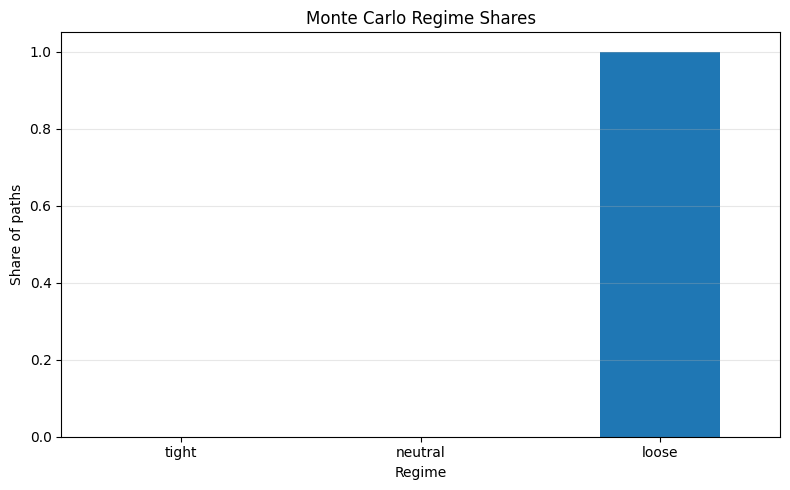

/var/folders/nf/0f78fmr95hz6c9cwnjjzzdlr0000gp/T/ipykernel_16284/2081286327.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data], labels=[path_summary["forecast_name"].iloc[0]], showmeans=True)


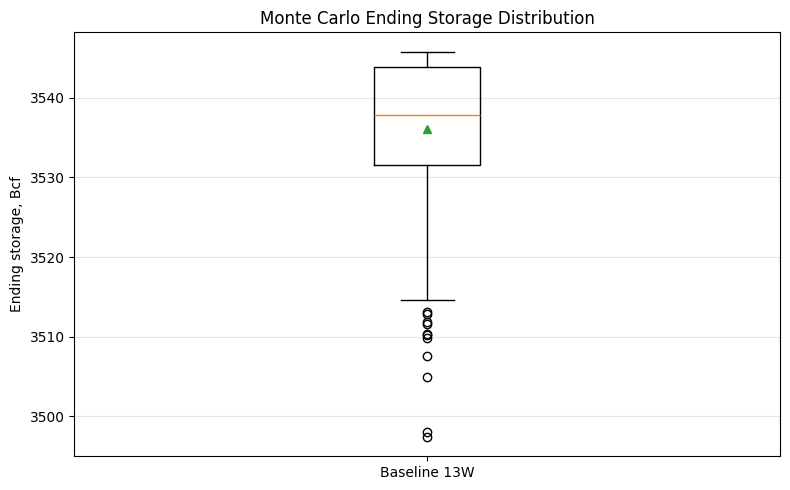

In [11]:
def plot_mc_regime_shares(shares):
    pivot = shares.set_index("path_regime")[["share"]]
    pivot = pivot.reindex(["tight", "neutral", "loose"]).fillna(0.0)

    ax = pivot.plot(kind="bar", legend=False, figsize=(8, 5))
    ax.set_title("Monte Carlo Regime Shares")
    ax.set_xlabel("Regime")
    ax.set_ylabel("Share of paths")
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_mc_ending_storage(path_summary):
    data = path_summary["ending_storage_bcf"].dropna()

    plt.figure(figsize=(8, 5))
    plt.boxplot([data], labels=[path_summary["forecast_name"].iloc[0]], showmeans=True)
    plt.title("Monte Carlo Ending Storage Distribution")
    plt.ylabel("Ending storage, Bcf")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

if "mc_regime_shares" in globals():
    plot_mc_regime_shares(mc_regime_shares)
    plot_mc_ending_storage(mc_path_summary)


## 10. Calibration grid review

Use this to see whether the selected parameters are stable or whether the “best” setting is fragile.


In [12]:
if "grid_df" in globals():
    display(grid_df.head(15))

    plt.figure(figsize=(8, 5))
    plt.hist(grid_df["objective"].dropna(), bins=20)
    plt.title("Calibration Objective Distribution")
    plt.xlabel("Objective score; lower is better")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No grid_df found. Skip this section if you did not run parameter grid search.")


No grid_df found. Skip this section if you did not run parameter grid search.


## 11. Final validation memo

This cell generates a plain-English memo you can use inside Energy Atlas or your own notes.


In [13]:
def build_validation_memo(metrics_df, scorecard, mc_confidence=None):
    m = metrics_df.iloc[0]
    failed = scorecard.loc[scorecard["status"] == "REVIEW", "test"].tolist()
    cadence = m.get("validation_cadence", "weekly")
    obs_label = "weeks" if cadence == "weekly" else "months"

    lines = []
    lines.append("## Model Validation Memo")
    lines.append("")
    lines.append(f"Backtest period contains **{int(m['n_observations'])} {obs_label}**.")
    lines.append(f"Storage level MAE is **{m['storage_level_mae_bcf']:.1f} Bcf** with bias of **{m['storage_level_bias_bcf']:.1f} Bcf**.")
    lines.append(f"Storage-change MAE is **{m['storage_change_mae_bcf']:.1f} Bcf**.")
    lines.append(f"Storage direction accuracy is **{m['storage_direction_accuracy']:.1%}**.")
    if not pd.isna(m['regime_accuracy']):
        lines.append(f"Tight / neutral / loose regime accuracy is **{m['regime_accuracy']:.1%}**.")
    lines.append("")

    if not failed:
        lines.append("**Conclusion:** The simulator is good enough for storage-focused directional use.")
    else:
        lines.append("**Conclusion:** The simulator is useful for storage direction, but the following gates need review before relying on it for stronger decisions:")
        for item in failed:
            lines.append(f"- {item}")

    if mc_confidence is not None:
        row = mc_confidence.iloc[0]
        lines.append("")
        lines.append("### Forward storage forecast")
        lines.append(
            f"- **{row['forecast_name']}**: dominant regime is **{row['dominant_regime']}** "
            f"with **{row['confidence']:.0%}** path agreement over **{int(row['horizon_steps'])} {row['path_cadence']}s**. "
            f"Expected ending storage is **{row['expected_ending_storage_bcf']:,.0f} Bcf** with a 10-90% range of "
            f"**{row['p10_ending_storage_bcf']:,.0f} to {row['p90_ending_storage_bcf']:,.0f} Bcf**."
        )

    return "\n".join(lines)


memo = build_validation_memo(metrics_df, scorecard, globals().get("mc_confidence"))
display(Markdown(memo))


## Model Validation Memo

Backtest period contains **435 weeks**.
Storage level MAE is **327.3 Bcf** with bias of **190.8 Bcf**.
Storage-change MAE is **31.1 Bcf**.
Storage direction accuracy is **92.2%**.
Tight / neutral / loose regime accuracy is **100.0%**.

**Conclusion:** The simulator is useful for storage direction, but the following gates need review before relying on it for stronger decisions:
- Storage level MAE
- Storage bias

### Forward storage forecast
- **Baseline 13W**: dominant regime is **loose** with **100%** path agreement over **13 weeks**. Expected ending storage is **3,536 Bcf** with a 10-90% range of **3,522 to 3,546 Bcf**.

## 12. Optional export

In [14]:
EXPORT_VALIDATION_OUTPUTS = False

if EXPORT_VALIDATION_OUTPUTS:
    validation_df.to_csv("storage_model_validation_backtest.csv", index=False)
    metrics_df.to_csv("storage_model_validation_metrics.csv", index=False)
    scorecard.to_csv("storage_model_validation_scorecard.csv", index=False)
    if "mc_confidence" in globals():
        mc_confidence.to_csv("storage_forecast_confidence.csv", index=False)
    with open("storage_model_validation_memo.md", "w") as f:
        f.write(memo)
    print("Exported storage validation outputs.")
